 # DEAI Classificatie - Ames Housing Dataset

 **Stap 1 & 2: Imports en Data Laden**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('AmesHousing.csv')


 ---

 # MODEL 1: Binaire Classificatie (Heeft het huis een garage?)

 **Stap 3: Target en Features bepalen**

 We maken eerst een target variabele aan.

In [7]:
# Creëer de binaire target: 1 = Wel een garage, 0 = Geen garage
df['Garage'] = (df['Garage'] == "yes").astype(int)

features_m1 = ['Year Built', 'Overall Qual', 'Neighborhood']
target_m1 = 'Garage'

df_m1 = df[features_m1 + [target_m1]].copy()
df_m1.dropna(inplace=True) # Verwijder rijen met missende waarden in onze selectie

print(f"Verdeling target:\n{df_m1['Garage'].value_counts()}")


Verdeling target:
Garage
1    2772
0     158
Name: count, dtype: int64


 **Stap 4: Data Voorbereiding (One-hot encoding & Splitten)**

In [8]:
# 4a. One-hot encode de categorische feature(s)
X_m1 = pd.get_dummies(df_m1[features_m1], drop_first=True)
y_m1 = df_m1[target_m1]

# 4b. Splits de dataset (Verticaal & Horizontaal)
X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_m1, y_m1, test_size=0.2, random_state=42)

print(f"Trainingsset grootte: {X_train_m1.shape}")
print(f"Testset grootte: {X_test_m1.shape}")


Trainingsset grootte: (2344, 29)
Testset grootte: (586, 29)


 **Stap 5 & 6: Initiële Run (Decision Tree Initialiseren, Trainen & Evalueren)**

--- EVALUATIE MODEL 1 (INITIËLE RUN) ---
Accuracy: 0.9283

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.14      0.19        37
           1       0.94      0.98      0.96       549

    accuracy                           0.93       586
   macro avg       0.64      0.56      0.58       586
weighted avg       0.91      0.93      0.91       586



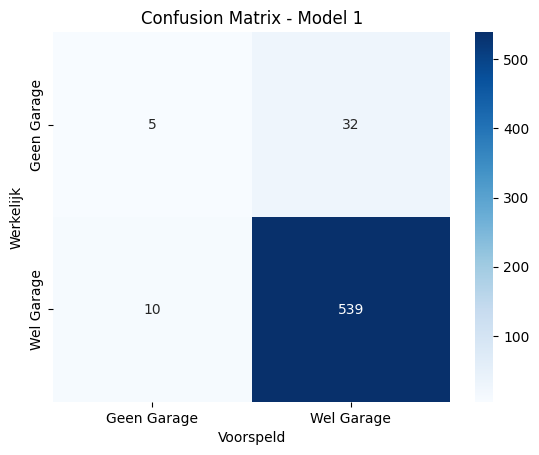

In [9]:
# 5. Model initialiseren met minimaal 2 hyperparameters (gebruik evt. help(DecisionTreeClassifier))
model_m1 = DecisionTreeClassifier(
    criterion='gini',       # Hyperparameter 1
    max_depth=5,            # Hyperparameter 2
    random_state=42
)

# Model trainen
model_m1.fit(X_train_m1, y_train_m1)

# 6. Evalueren op de testset
y_pred_m1 = model_m1.predict(X_test_m1)

print("--- EVALUATIE MODEL 1 (INITIËLE RUN) ---")
print(f"Accuracy: {accuracy_score(y_test_m1, y_pred_m1):.4f}\n")
print("Classification Report:")
print(classification_report(y_test_m1, y_pred_m1))

# Confusion Matrix Visualisatie
cm = confusion_matrix(y_test_m1, y_pred_m1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Geen Garage', 'Wel Garage'],
            yticklabels=['Geen Garage', 'Wel Garage'])
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijk')
plt.title('Confusion Matrix - Model 1')
plt.show()


 ---

 # MODEL 2: Multi-Class Classificatie (Kwaliteitsniveau 'Overall Qual')

 **Stap 3: Target en Features bepalen**

In [10]:
# Target is nu 'Overall Qual' (Schaal 1 tot 10)
target_m2 = 'Overall Qual'

# Top 3 features (minimaal 1 categorisch)
# Voorbeeldkeuze: Woonoppervlakte (num), Kavelgrootte (num), Huisstijl (cat)
features_m2 = ['Gr Liv Area', 'Lot Area', 'House Style']

df_m2 = df[features_m2 + [target_m2]].copy()
df_m2.dropna(inplace=True)

print(f"Verdeling target (Kwaliteit 1 t/m 10):\n{df_m2[target_m2].value_counts().sort_index()}")


Verdeling target (Kwaliteit 1 t/m 10):
Overall Qual
1       4
2      13
3      40
4     226
5     825
6     732
7     602
8     350
9     107
10     31
Name: count, dtype: int64


 **Stap 4: Data Voorbereiding**

In [11]:
# 4a. One-hot encode
X_m2 = pd.get_dummies(df_m2[features_m2], drop_first=True)
y_m2 = df_m2[target_m2]

# 4b. Splitten
X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_m2, y_m2, test_size=0.2, random_state=42)


 **Stap 5 & 6: Initiële Run (Decision Tree Trainen & Evalueren)**

--- EVALUATIE MODEL 2 (INITIËLE RUN) ---
Accuracy: 0.4113



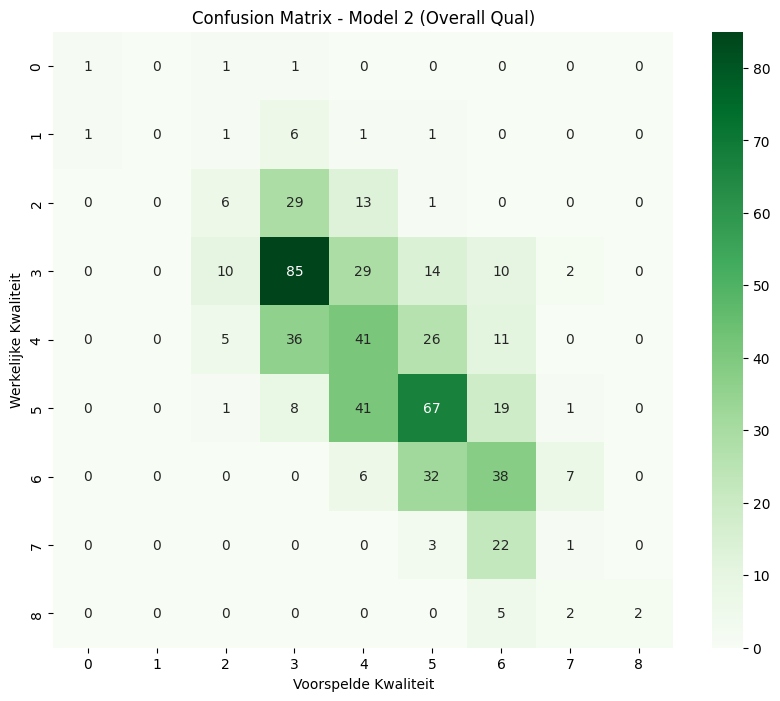

In [12]:
# 5. Model initialiseren
model_m2 = DecisionTreeClassifier(
    max_depth=6,             # Hyperparameter 1
    min_samples_leaf=4,      # Hyperparameter 2
    random_state=42
)

# Trainen
model_m2.fit(X_train_m2, y_train_m2)

# 6. Evalueren
y_pred_m2 = model_m2.predict(X_test_m2)

print("--- EVALUATIE MODEL 2 (INITIËLE RUN) ---")
print(f"Accuracy: {accuracy_score(y_test_m2, y_pred_m2):.4f}\n")

# Let op: bij multi-class is een confusion matrix veel groter
plt.figure(figsize=(10,8))
cm_m2 = confusion_matrix(y_test_m2, y_pred_m2)
sns.heatmap(cm_m2, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Voorspelde Kwaliteit')
plt.ylabel('Werkelijke Kwaliteit')
plt.title('Confusion Matrix - Model 2 (Overall Qual)')
plt.show()
